In [1]:
import numpy as np 
import pandas as pd 

# Read JSON File

## **Parties Table**

In [59]:
parties = pd.read_json("pr_parties.json")
parties

,lastUpdated,totalPrVotes,parties,sourceFile
0,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2528', 'partyName': 'राष्ट्रिय स्...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
1,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2583', 'partyName': 'नेपाली काँग्...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
2,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2598', 'partyName': 'नेपाल कम्युन...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
3,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2557', 'partyName': 'नेपाली कम्यु...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
4,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2501', 'partyName': 'श्रम संस्कृत...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
5,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2604', 'partyName': 'राष्ट्रिय प्...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
6,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2542', 'partyName': 'जनता समाजवाद...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
7,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2568', 'partyName': 'राष्ट्रिय पर...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
8,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2585', 'partyName': 'जनमत पार्टी'...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt
9,2026-06-30T21:28:05.771Z,10835025,"{'partyId': '2531', 'partyName': 'एकल चिन्ह चक...",JSONFiles/Election2082/Common/PRHoRPartyTop5.txt


- *The JSON file is not formatted as expected, so it may need additional processing before it can be used.*

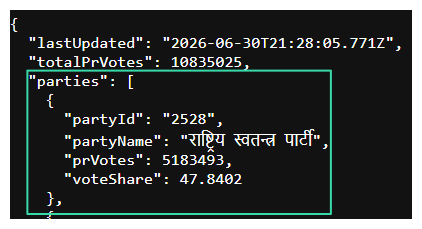

### **Reading Nested JSON**
If your JSON is deeply nested (e.g., dictionaries inside dictionaries), the standard `read_json` might put entire objects into a single cell. You can use `json_normalize` to flatten this structure.

---
```python
import pandas as pd
import json

# 1. Load the raw JSON data
with open('nested_data.json', 'r') as f:
    data = json.load(f)

# 2. Flatten the 'parties' list into a DataFrame
# 'record_path' points to the list you want to turn into rows
# 'meta' adds the top-level fields to every row
df = pd.json_normalize(
    data, 
    record_path=['parties'], 
    meta=['lastUpdated', 'totalPrVotes']
)

print(df)
```
---

In [60]:
# Alternate

In [61]:
import json

with open('pr_parties.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

data

{'lastUpdated': '2026-06-30T21:28:05.771Z',
 'totalPrVotes': 10835025,
 'parties': [{'partyId': '2528',
   'partyName': 'राष्ट्रिय स्वतन्त्र पार्टी',
   'prVotes': 5183493,
   'voteShare': 47.8402},
  {'partyId': '2583',
   'partyName': 'नेपाली काँग्रेस',
   'prVotes': 1759172,
   'voteShare': 16.236},
  {'partyId': '2598',
   'partyName': 'नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी लेनिनवादी)',
   'prVotes': 1455885,
   'voteShare': 13.4368},
  {'partyId': '2557',
   'partyName': 'नेपाली कम्युनिष्ट पार्टी',
   'prVotes': 811577,
   'voteShare': 7.4903},
  {'partyId': '2501',
   'partyName': 'श्रम संस्कृति पार्टी',
   'prVotes': 385902,
   'voteShare': 3.5616},
  {'partyId': '2604',
   'partyName': 'राष्ट्रिय प्रजातन्त्र पार्टी',
   'prVotes': 330684,
   'voteShare': 3.052},
  {'partyId': '2542',
   'partyName': 'जनता समाजवादी पार्टी, नेपाल',
   'prVotes': 182285,
   'voteShare': 1.6824},
  {'partyId': '2568',
   'partyName': 'राष्ट्रिय परिवर्तन पार्टी',
   'prVotes': 172489,
   'vote

In [62]:
parties = pd.DataFrame(data['parties'])
parties

,partyId,partyName,prVotes,voteShare
0,2528,राष्ट्रिय स्वतन्त्र पार्टी,5183493,47.8402
1,2583,नेपाली काँग्रेस,1759172,16.2360
2,2598,नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी ले...,1455885,13.4368
3,2557,नेपाली कम्युनिष्ट पार्टी,811577,7.4903
4,2501,श्रम संस्कृति पार्टी,385902,3.5616
5,2604,राष्ट्रिय प्रजातन्त्र पार्टी,330684,3.0520
6,2542,"जनता समाजवादी पार्टी, नेपाल",182285,1.6824
7,2568,राष्ट्रिय परिवर्तन पार्टी,172489,1.5920
8,2585,जनमत पार्टी,79435,0.7331
9,2531,एकल चिन्ह चकिया (जाँतो) (राष्ट्रिय मुक्ति पार्...,62069,0.5729


## **Constituencies Table**

In [63]:
constituencies = pd.read_json('constituencies.json')
constituencies

,province,district,districtNp,code,name,nameNp,status,lastUpdated,candidates,votesCast,totalVoters
0,Koshi,Taplejung,ताप्लेजुङ,1-ताप्लेजुङ-1,Taplejung-1,ताप्लेजुङ क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 339933, 'nameNp': 'क्षितिज थे...",42897,90308
1,Koshi,Panchthar,पाँचथर,1-पाँचथर-1,Panchthar-1,पाँचथर क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340563, 'nameNp': 'नरेन्द्र क...",66921,143358
2,Koshi,Ilam,इलाम,1-इलाम-1,Ilam-1,इलाम क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340081, 'nameNp': 'निश्कल राई...",59391,112296
3,Koshi,Ilam,इलाम,1-इलाम-2,Ilam-2,इलाम क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 339922, 'nameNp': 'सुहाङ नेम्...",63781,119475
4,Koshi,Jhapa,झापा,1-झापा-1,Jhapa-1,झापा क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 339485, 'nameNp': 'निशा डाँगी...",78291,130993
...,...,...,...,...,...,...,...,...,...,...,...
160,Sudurpashchim,Kanchanpur,कञ्चनपुर,7-कञ्चनपुर-2,Kanchanpur-2,कञ्चनपुर क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340896, 'nameNp': 'दिपक राज ब...",61117,109572
161,Sudurpashchim,Kanchanpur,कञ्चनपुर,7-कञ्चनपुर-3,Kanchanpur-3,कञ्चनपुर क्षेत्र नं. 3,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340127, 'nameNp': 'ज्ञानेन्द्...",53546,103087
162,Lumbini,Parasi,नवलपरासी (बर्दघाट सुस्ता पश्चिम),5-नवलपरासी (बर्दघाट सुस्ता पश्चिम)-1,Parasi-1,नवलपरासी (बर्दघाट सुस्ता पश्चिम) क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340029, 'nameNp': 'विक्रम खना...",77089,123072
163,Lumbini,Parasi,नवलपरासी (बर्दघाट सुस्ता पश्चिम),5-नवलपरासी (बर्दघाट सुस्ता पश्चिम)-2,Parasi-2,नवलपरासी (बर्दघाट सुस्ता पश्चिम) क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340191, 'nameNp': 'नरेन्द्र क...",83456,131049


### **Handling Different JSON Structures**
JSON files can be structured in various ways (*records*, *index*, *columns*, *split*). The `orient` parameter helps pandas interpret the format correctly.

Common orient Options:

* ***records***: List like `[{col: val}, {col: val}]` (most common).
* ***index***: Dictionary like `{index: {col: val}}`.
* ***columns***: Dictionary like `{col: {index: val}}`.
* ***split***: Dictionary containing separate entries for indexes, columns, and data.

In [64]:
constituencies = pd.read_json('constituencies.json')
constituencies

,province,district,districtNp,code,name,nameNp,status,lastUpdated,candidates,votesCast,totalVoters
0,Koshi,Taplejung,ताप्लेजुङ,1-ताप्लेजुङ-1,Taplejung-1,ताप्लेजुङ क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 339933, 'nameNp': 'क्षितिज थे...",42897,90308
1,Koshi,Panchthar,पाँचथर,1-पाँचथर-1,Panchthar-1,पाँचथर क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340563, 'nameNp': 'नरेन्द्र क...",66921,143358
2,Koshi,Ilam,इलाम,1-इलाम-1,Ilam-1,इलाम क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340081, 'nameNp': 'निश्कल राई...",59391,112296
3,Koshi,Ilam,इलाम,1-इलाम-2,Ilam-2,इलाम क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 339922, 'nameNp': 'सुहाङ नेम्...",63781,119475
4,Koshi,Jhapa,झापा,1-झापा-1,Jhapa-1,झापा क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 339485, 'nameNp': 'निशा डाँगी...",78291,130993
...,...,...,...,...,...,...,...,...,...,...,...
160,Sudurpashchim,Kanchanpur,कञ्चनपुर,7-कञ्चनपुर-2,Kanchanpur-2,कञ्चनपुर क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340896, 'nameNp': 'दिपक राज ब...",61117,109572
161,Sudurpashchim,Kanchanpur,कञ्चनपुर,7-कञ्चनपुर-3,Kanchanpur-3,कञ्चनपुर क्षेत्र नं. 3,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340127, 'nameNp': 'ज्ञानेन्द्...",53546,103087
162,Lumbini,Parasi,नवलपरासी (बर्दघाट सुस्ता पश्चिम),5-नवलपरासी (बर्दघाट सुस्ता पश्चिम)-1,Parasi-1,नवलपरासी (बर्दघाट सुस्ता पश्चिम) क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340029, 'nameNp': 'विक्रम खना...",77089,123072
163,Lumbini,Parasi,नवलपरासी (बर्दघाट सुस्ता पश्चिम),5-नवलपरासी (बर्दघाट सुस्ता पश्चिम)-2,Parasi-2,नवलपरासी (बर्दघाट सुस्ता पश्चिम) क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,"[{'candidateId': 340191, 'nameNp': 'नरेन्द्र क...",83456,131049


In [65]:
cols = constituencies.columns

cols = cols[~(cols == 'candidates')]

constituencies = constituencies[cols]
constituencies

,province,district,districtNp,code,name,nameNp,status,lastUpdated,votesCast,totalVoters
0,Koshi,Taplejung,ताप्लेजुङ,1-ताप्लेजुङ-1,Taplejung-1,ताप्लेजुङ क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,42897,90308
1,Koshi,Panchthar,पाँचथर,1-पाँचथर-1,Panchthar-1,पाँचथर क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,66921,143358
2,Koshi,Ilam,इलाम,1-इलाम-1,Ilam-1,इलाम क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,59391,112296
3,Koshi,Ilam,इलाम,1-इलाम-2,Ilam-2,इलाम क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,63781,119475
4,Koshi,Jhapa,झापा,1-झापा-1,Jhapa-1,झापा क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,78291,130993
...,...,...,...,...,...,...,...,...,...,...
160,Sudurpashchim,Kanchanpur,कञ्चनपुर,7-कञ्चनपुर-2,Kanchanpur-2,कञ्चनपुर क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,61117,109572
161,Sudurpashchim,Kanchanpur,कञ्चनपुर,7-कञ्चनपुर-3,Kanchanpur-3,कञ्चनपुर क्षेत्र नं. 3,DECLARED,2026-06-30T21:28:05.771Z,53546,103087
162,Lumbini,Parasi,नवलपरासी (बर्दघाट सुस्ता पश्चिम),5-नवलपरासी (बर्दघाट सुस्ता पश्चिम)-1,Parasi-1,नवलपरासी (बर्दघाट सुस्ता पश्चिम) क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,77089,123072
163,Lumbini,Parasi,नवलपरासी (बर्दघाट सुस्ता पश्चिम),5-नवलपरासी (बर्दघाट सुस्ता पश्चिम)-2,Parasi-2,नवलपरासी (बर्दघाट सुस्ता पश्चिम) क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,83456,131049


In [66]:
constituencies

,province,district,districtNp,code,name,nameNp,status,lastUpdated,votesCast,totalVoters
0,Koshi,Taplejung,ताप्लेजुङ,1-ताप्लेजुङ-1,Taplejung-1,ताप्लेजुङ क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,42897,90308
1,Koshi,Panchthar,पाँचथर,1-पाँचथर-1,Panchthar-1,पाँचथर क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,66921,143358
2,Koshi,Ilam,इलाम,1-इलाम-1,Ilam-1,इलाम क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,59391,112296
3,Koshi,Ilam,इलाम,1-इलाम-2,Ilam-2,इलाम क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,63781,119475
4,Koshi,Jhapa,झापा,1-झापा-1,Jhapa-1,झापा क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,78291,130993
...,...,...,...,...,...,...,...,...,...,...
160,Sudurpashchim,Kanchanpur,कञ्चनपुर,7-कञ्चनपुर-2,Kanchanpur-2,कञ्चनपुर क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,61117,109572
161,Sudurpashchim,Kanchanpur,कञ्चनपुर,7-कञ्चनपुर-3,Kanchanpur-3,कञ्चनपुर क्षेत्र नं. 3,DECLARED,2026-06-30T21:28:05.771Z,53546,103087
162,Lumbini,Parasi,नवलपरासी (बर्दघाट सुस्ता पश्चिम),5-नवलपरासी (बर्दघाट सुस्ता पश्चिम)-1,Parasi-1,नवलपरासी (बर्दघाट सुस्ता पश्चिम) क्षेत्र नं. 1,DECLARED,2026-06-30T21:28:05.771Z,77089,123072
163,Lumbini,Parasi,नवलपरासी (बर्दघाट सुस्ता पश्चिम),5-नवलपरासी (बर्दघाट सुस्ता पश्चिम)-2,Parasi-2,नवलपरासी (बर्दघाट सुस्ता पश्चिम) क्षेत्र नं. 2,DECLARED,2026-06-30T21:28:05.771Z,83456,131049


## **Candidates Table**

In [67]:
with open('constituencies.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

candidates = pd.json_normalize(data, record_path='candidates', meta=['code'])
candidates

,candidateId,nameNp,name,partyName,partyId,votes,gender,isWinner,fatherName,qualification,institution,address,spouseName,experience,code
0,339933,क्षितिज थेबे,Khitiz Thebe,नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी ले...,2598,13962,M,True,भुपेन्द्र थेबे,स्नातक,TU,ताप्लेजुङ सिरीजङ्घा गाउँपालिका मादिबुङ,NaN,NaN,1-ताप्लेजुङ-1
1,341131,गजेन्द्र प्रसाद तुम्याङ लिम्बु,Gajendra Prasad Tumyang Limbu,नेपाली काँग्रेस,2583,11711,M,False,Purna Bahadur Limbu,स्नातक,पाथीभरा वहुमुखी क्याम्पस,Taplejung,Radhika Lingden Tumyang,NaN,1-ताप्लेजुङ-1
2,339610,खेल प्रसाद बुडाक्षेत्री,Khel Prasad Buda Chhetri,नेपाली कम्युनिष्ट पार्टी,2557,6775,M,False,शम्सेर बहादुर बुडाक्षेत्री,I.s.c,TU,ताप्लेजुङ सिरीजङ्घा गाउँपालिका चिचिहाङ्ग,कुमारी बुडाक्षेत्री,NaN,1-ताप्लेजुङ-1
3,340005,सन्तोष राई,Santosh Rai,श्रम संस्कृति पार्टी,2501,5209,M,False,Bal Bahadur Rai,कक्षा ८,गणेश मा.वि. खेवाङ,Taplejung,Sita Rai,NaN,1-ताप्लेजुङ-1
4,340459,बिरेन्द्र श्रेष्ठ,Birendra Shrestha,राष्ट्रिय स्वतन्त्र पार्टी,2528,4155,M,False,Tek Bahadur Shrestha,ईन्जिनेरिङ ग्राजुएड,युनिभर सिटी आर्मानिय,Taplejung,Manolak Wuphashree Shrestha,NaN,1-ताप्लेजुङ-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3401,339584,सत्‍यनारायण श्रेष्ठ,Sat‍yanarayana Shreshth,राष्ट्रिय जनमोर्चा,2522,170,M,False,चित्रबहादुर श्रेष्ठ,आठ कक्षा उतिर्ण,श्री मा.वि. थवाङ्ग,रुकुम (पश्चिम भाग) मुसिकोट नगरपालिका खलंगा,शीतली माया श्रेष्ठ,NaN,6-रुकुम (पश्चिम भाग)-1
3402,341508,नरेन्द्र के.सी,Narendra Ke.si,उज्यालो नेपाल पार्टी,2566,84,M,False,पुस्प्रसिंह के.सी,स्नातकोत्तर,त्रि.वि.वि./ खुला बिश्वविद्यालय भारत,रुकुम (पश्चिम भाग) आठबिसकोट नगरपालिका फारुला,विणा शर्मा,राष्ट्रिय अन्तर्राष्ट्रिय गैरसरकारी संस्थामा २...,6-रुकुम (पश्चिम भाग)-1
3403,341627,शेर बहादुर के.सी.,Shera Bahadura Ke.si.,नेपाल कम्युनिष्ट पार्टी (संयुक्त),2601,54,M,False,दिलबहादुर के.सी.,प्रमाणपत्र तह,NaN,रुकुम (पश्चिम भाग) चौरजहारी नगरपालिका देउरालटा...,"तुल्सीर पुष्पा,टेका के.सी.",शिक्षा सास्त्र संस्थान नेपालगञ्ज,6-रुकुम (पश्चिम भाग)-1
3404,341758,प्रेमा दमाई नेपाली,Prema Damaee Nepali,आम जनता पार्टी(एकल चुनाव चिन्ह),2581,45,F,False,धर्मे दमाई,आधारभुत तह,जनजागृति मा.वि. साँख,रुकुम (पश्चिम भाग) मुसिकोट नगरपालिका सालघारी,दलवहादुर नेपाली,10 वर्ष राजनितकअनुभव,6-रुकुम (पश्चिम भाग)-1


### **Age Data**

In [68]:
age = pd.read_json("ElectionResultCentral2082.json", encoding='utf-8-sig')    # lines=False

In [69]:
age.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3406 entries, 0 to 3405
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CandidateID         3406 non-null   int64  
 1   CandidateName       3406 non-null   object 
 2   AGE_YR              3406 non-null   int64  
 3   Gender              3406 non-null   object 
 4   PoliticalPartyName  3406 non-null   object 
 5   SYMBOLCODE          3406 non-null   int64  
 6   SymbolName          3406 non-null   object 
 7   CTZDIST             3395 non-null   object 
 8   DistrictName        3406 non-null   object 
 9   StateName           3406 non-null   object 
 10  STATE_ID            3406 non-null   int64  
 11  SCConstID           3406 non-null   int64  
 12  ConstName           3406 non-null   int64  
 13  TotalVoteReceived   3406 non-null   int64  
 14  R                   3406 non-null   int64  
 15  E_STATUS            0 non-null      float64
 16  DOB   

In [70]:
age.columns

Index(['CandidateID', 'CandidateName', 'AGE_YR', 'Gender',
       'PoliticalPartyName', 'SYMBOLCODE', 'SymbolName', 'CTZDIST',
       'DistrictName', 'StateName', 'STATE_ID', 'SCConstID', 'ConstName',
       'TotalVoteReceived', 'R', 'E_STATUS', 'DOB', 'FATHER_NAME',
       'SPOUCE_NAME', 'QUALIFICATION', 'NAMEOFINST', 'EXPERIENCE',
       'OTHERDETAILS', 'ADDRESS'],
      dtype='object')

In [71]:
age = age[['CandidateID', 'AGE_YR']]
age

,CandidateID,AGE_YR
0,339933,38
1,341131,46
2,339610,50
3,340459,55
4,340160,63
...,...,...
3401,340871,62
3402,341627,70
3403,341199,37
3404,341508,48


In [72]:
candidates = candidates.merge(age, how='inner', left_on='candidateId', right_on='CandidateID')
candidates.head()

,candidateId,nameNp,name,partyName,partyId,votes,gender,isWinner,fatherName,qualification,institution,address,spouseName,experience,code,CandidateID,AGE_YR
0,339933,क्षितिज थेबे,Khitiz Thebe,नेपाल कम्युनिष्ट पार्टी (एकीकृत मार्क्सवादी ले...,2598,13962,M,True,भुपेन्द्र थेबे,स्नातक,TU,ताप्लेजुङ सिरीजङ्घा गाउँपालिका मादिबुङ,NaN,NaN,1-ताप्लेजुङ-1,339933,38
1,341131,गजेन्द्र प्रसाद तुम्याङ लिम्बु,Gajendra Prasad Tumyang Limbu,नेपाली काँग्रेस,2583,11711,M,False,Purna Bahadur Limbu,स्नातक,पाथीभरा वहुमुखी क्याम्पस,Taplejung,Radhika Lingden Tumyang,NaN,1-ताप्लेजुङ-1,341131,46
2,339610,खेल प्रसाद बुडाक्षेत्री,Khel Prasad Buda Chhetri,नेपाली कम्युनिष्ट पार्टी,2557,6775,M,False,शम्सेर बहादुर बुडाक्षेत्री,I.s.c,TU,ताप्लेजुङ सिरीजङ्घा गाउँपालिका चिचिहाङ्ग,कुमारी बुडाक्षेत्री,NaN,1-ताप्लेजुङ-1,339610,50
3,340005,सन्तोष राई,Santosh Rai,श्रम संस्कृति पार्टी,2501,5209,M,False,Bal Bahadur Rai,कक्षा ८,गणेश मा.वि. खेवाङ,Taplejung,Sita Rai,NaN,1-ताप्लेजुङ-1,340005,49
4,340459,बिरेन्द्र श्रेष्ठ,Birendra Shrestha,राष्ट्रिय स्वतन्त्र पार्टी,2528,4155,M,False,Tek Bahadur Shrestha,ईन्जिनेरिङ ग्राजुएड,युनिभर सिटी आर्मानिय,Taplejung,Manolak Wuphashree Shrestha,NaN,1-ताप्लेजुङ-1,340459,55


In [73]:
candidates.columns

Index(['candidateId', 'nameNp', 'name', 'partyName', 'partyId', 'votes',
       'gender', 'isWinner', 'fatherName', 'qualification', 'institution',
       'address', 'spouseName', 'experience', 'code', 'CandidateID', 'AGE_YR'],
      dtype='object')

# Export DataFrame into CSV File

In [75]:
parties.to_csv('parties.csv', index=False)

In [76]:
constituencies.to_csv('constituencies.csv', index=False)

In [77]:
candidates.to_csv('candidates.csv', index=False)

In [78]:
np.save(file='candidate_id.npy', arr=candidates['candidateId'])